# Notebook 03 - Exploratory Data Analysis

## Sections
- Dataset Overview
- Target Variable Analysis
- Age Distribution
- Gender Distribution
- Race Distribution
- Hospital Stay Analysis
- Correlation Analysis
- Business Insights
- Summary

In [1]:
# ============================================================
# Notebook 03 : Exploratory Data Analysis (EDA)
# Healthcare Readmission Analytics
#
# Objectives
# ------------------------------------------------------------
# 1. Explore patient characteristics
# 2. Analyze feature distributions
# 3. Understand readmission patterns
# 4. Generate business insights
# 5. Create professional visualizations
# 1---============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# Plot Theme
sns.set_theme(style="whitegrid", context="notebook")

# Global Colors
PRIMARY_COLOR = "#2563eb"
SECONDARY_COLOR = "#60a5fa"
FEMALE_COLOR = "#ec4899"
MALE_COLOR = "#3b82f6"
NEUTRAL_COLOR = "#9ca3af"

In [2]:
# ============================================================
# 2-Load Clean Dataset
# ============================================================

df = pd.read_csv("../data/processed/diabetic_data_clean.csv")

In [3]:
# ============================================================
# 3---Dataset Overview
# ============================================================

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.head())

Rows    : 101766
Columns : 45


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,250.83,276,250,1,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,276,250.01,255,9,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,648,250,V27,6,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,8,250.43,403,7,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,197,157,250,5,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


readmitted
<30    11357
>30    35545
NO     54864
Name: count, dtype: int64

Percentage Distribution

readmitted
<30    11.16
>30    34.93
NO     53.91
Name: count, dtype: float64


C:\Users\Jaimul haque\AppData\Local\Temp\ipykernel_21744\2318808284.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


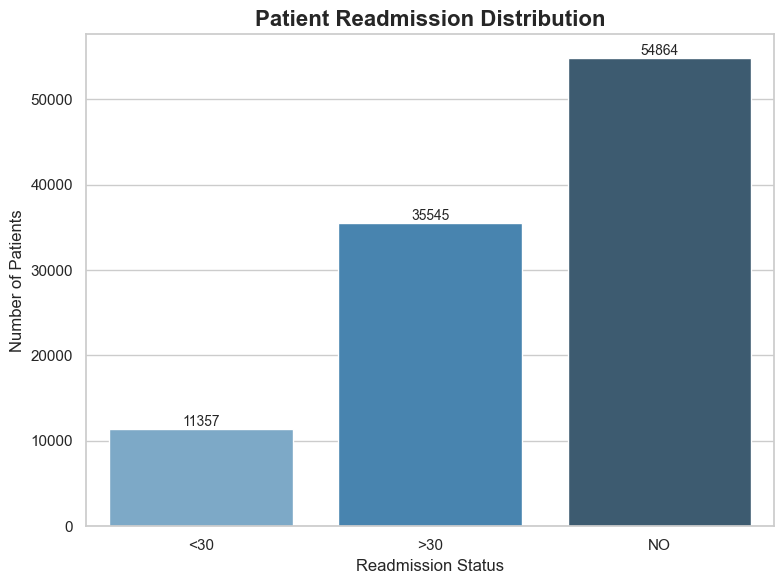

In [4]:
# ============================================================
# 4-Target Variable Analysis
# ============================================================

target_counts = df["readmitted"].value_counts().sort_index()

print(target_counts)

print("\nPercentage Distribution\n")

print((target_counts / len(df) * 100).round(2))

plt.figure(figsize=(8,6))

ax = sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    palette="Blues_d"
)

plt.title("Patient Readmission Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=10)

plt.tight_layout()

plt.savefig(
    "../images/readmission_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Target Variable Observation

## Finding
- 54,864 patients (53.91%) were not readmitted after discharge.
- 35,545 patients (34.93%) were readmitted after 30 days.
- 11,357 patients (11.16%) were readmitted within 30 days.

## Business Interpretation
More than half of the patients were not readmitted, indicating a positive outcome for many hospital visits. However, nearly 46% of patients experienced readmission, suggesting that hospital readmission remains a significant healthcare concern.

## Why It Matters
The target variable is moderately imbalanced. During model development, evaluation should not rely only on accuracy. Metrics such as Precision, Recall, F1-score, and ROC-AUC will provide a more reliable assessment.

readmitted
<30    11357
>30    35545
NO     54864
Name: count, dtype: int64

Percentage Distribution

readmitted
<30    11.16
>30    34.93
NO     53.91
Name: count, dtype: float64


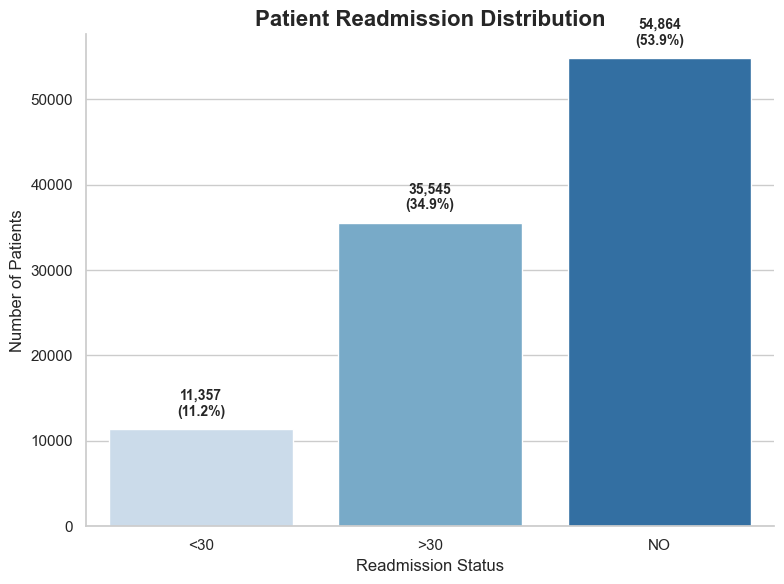

In [5]:
# ============================================================
# Target Variable Analysis
# ============================================================

target_counts = df["readmitted"].value_counts().sort_index()

print(target_counts)

target_percentage = (target_counts / len(df) * 100).round(2)

print("\nPercentage Distribution\n")
print(target_percentage)

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    hue=target_counts.index,
    palette="Blues",
    legend=False
)

plt.title(
    "Patient Readmission Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Readmission Status", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

# Add Count + Percentage Labels
for i, bar in enumerate(ax.patches):

    count = target_counts.iloc[i]
    percentage = target_percentage.iloc[i]

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1200,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/readmission_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Target Variable Observation

## 📊 Finding

- **53.91%** of patients were **not readmitted** after discharge.
- **34.93%** of patients were **readmitted after 30 days**.
- **11.16%** of patients were **readmitted within 30 days**.
- Nearly **46%** of all patients experienced at least one hospital readmission.

---

## 💡 Business Interpretation

Hospital readmission remains a significant healthcare challenge. Although most patients were not readmitted, almost half returned to the hospital after discharge. Reducing readmission rates can improve patient outcomes while lowering healthcare costs.

---

## 🎯 Why It Matters

- The target variable is **moderately imbalanced**, with "NO" being the majority class.
- Model evaluation should not rely only on **Accuracy**.
- Metrics such as **Precision, Recall, F1-Score, and ROC-AUC** will provide a more reliable evaluation.
- Since predicting readmission is the primary business objective, the **readmitted** column will be used as the target variable in the machine learning phase.

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64


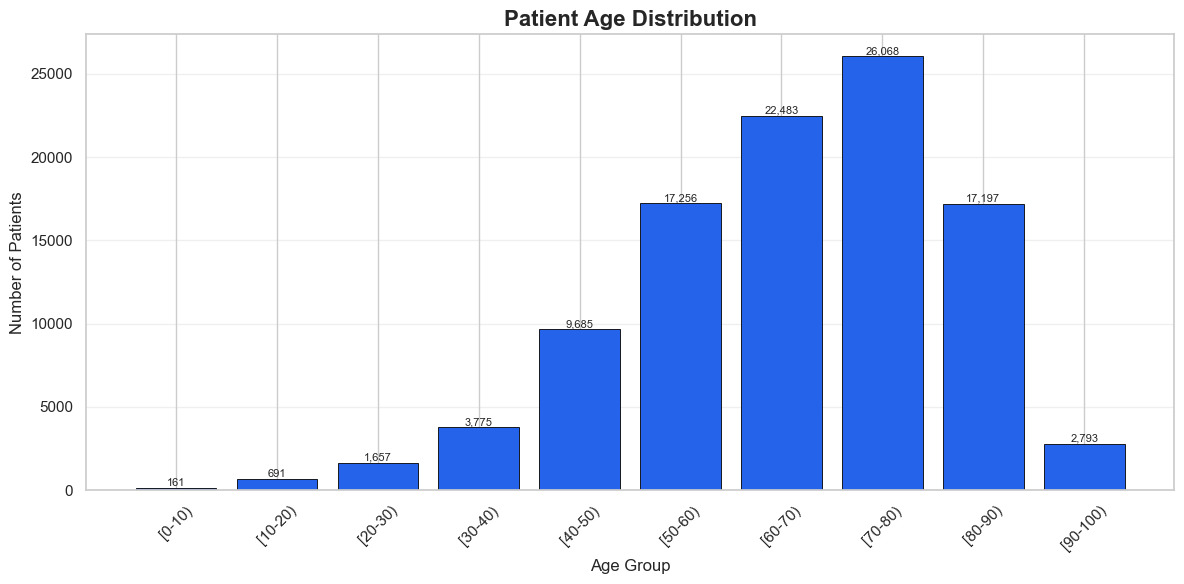

In [6]:
# ============================================================
# Age Distribution
# ============================================================

age_counts = df["age"].value_counts().sort_index()

print(age_counts)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    age_counts.index,
    age_counts.values,
    color="#2563eb",
    edgecolor="black",
    linewidth=0.6
)

plt.title("Patient Age Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Patients", fontsize=12)

plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../images/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Age Distribution Observation

## 📊 Finding

- The largest patient group falls within the **70–80 years** age range (26,068 patients).
- Patients aged **60–70 years** represent the second-largest group (22,483 patients).
- The number of hospitalized patients increases steadily with age until 80 years, after which it declines.
- Patients below 40 years account for only a small proportion of the dataset.

---

## 💡 Business Interpretation

The dataset is dominated by older adults, indicating that diabetes-related hospital admissions occur more frequently among elderly patients. This reflects the higher prevalence of diabetes complications in later stages of life.

---

## 🎯 Why It Matters

- Age is expected to be one of the strongest predictors of hospital readmission.
- Elderly patients may require closer monitoring and follow-up care after discharge.
- Age should be retained as an important feature during machine learning model development.

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


C:\Users\Jaimul haque\AppData\Local\Temp\ipykernel_21744\3334954506.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


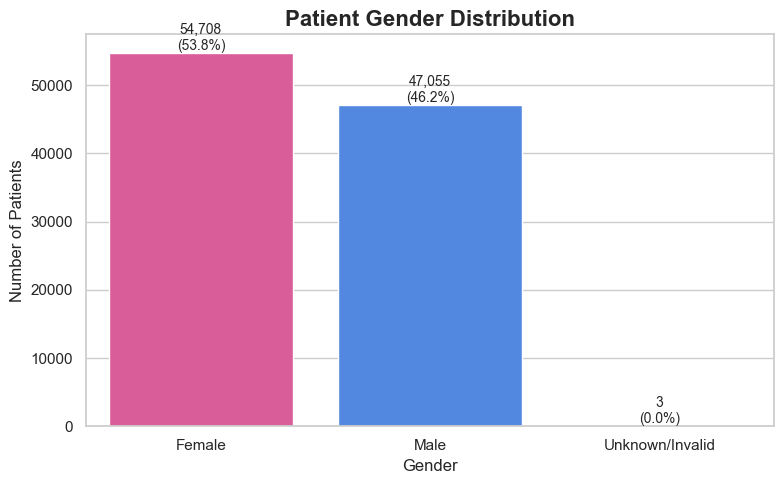

In [7]:
# ============================================================
# Gender Distribution
# ============================================================

gender_counts = df["gender"].value_counts()

print(gender_counts)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values,
    palette=[FEMALE_COLOR, MALE_COLOR, NEUTRAL_COLOR][:len(gender_counts)]
)

plt.title("Patient Gender Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

total = gender_counts.sum()

for i, container in enumerate(ax.containers):
    count = gender_counts.iloc[i]
    percentage = (count / total) * 100

    ax.bar_label(
        container,
        labels=[f"{count:,}\n({percentage:.1f}%)"],
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "../images/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Gender Distribution Observation

## 📊 Finding

- Female patients account for **54,708** hospital visits.
- Male patients account for **47,055** hospital visits.
- Only **3** records are labeled as **Unknown/Invalid**.
- The dataset shows a well-balanced gender distribution with a slight predominance of female patients.

---

## 💡 Business Interpretation

Both male and female patients are strongly represented in the dataset. The balanced distribution reduces the likelihood of gender-related sampling bias in predictive modeling.

---

## 🎯 Why It Matters

- Gender can be included as a predictive feature.
- However, clinical variables such as age, diagnosis, and hospital stay are expected to have a greater influence on readmission prediction.

race
Caucasian          78372
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


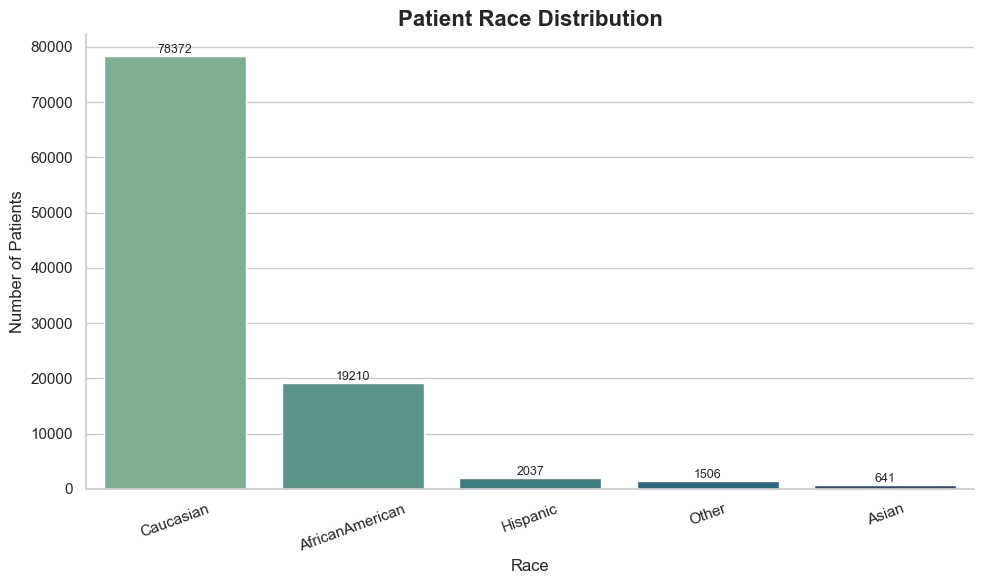

In [8]:
# ============================================================
# Race Distribution
# ============================================================

race_counts = df["race"].value_counts()

print(race_counts)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=race_counts.index,
    y=race_counts.values,
    hue=race_counts.index,
    palette="crest",
    legend=False
)

plt.title("Patient Race Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Race")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=9)

plt.xticks(rotation=20)

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/race_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Race Distribution Observation

## 📊 Finding

- **Caucasian** patients represent the majority of the dataset (**78,372** records).
- **African American** patients form the second-largest group (**19,210** records).
- Hispanic, Other, and Asian patients represent relatively small proportions of the dataset.

---

## 💡 Business Interpretation

The dataset is dominated by Caucasian patients, indicating that the hospital population is not evenly distributed across racial groups. This imbalance should be considered when interpreting model performance across different populations.

---

## 🎯 Why It Matters

- Race may contribute useful information for readmission prediction.
- However, the class imbalance should be considered to avoid biased conclusions and ensure fair model evaluation.

time_in_hospital
1     14208
2     17224
3     17756
4     13924
5      9966
6      7539
7      5859
8      4391
9      3002
10     2342
11     1855
12     1448
13     1210
14     1042
Name: count, dtype: int64


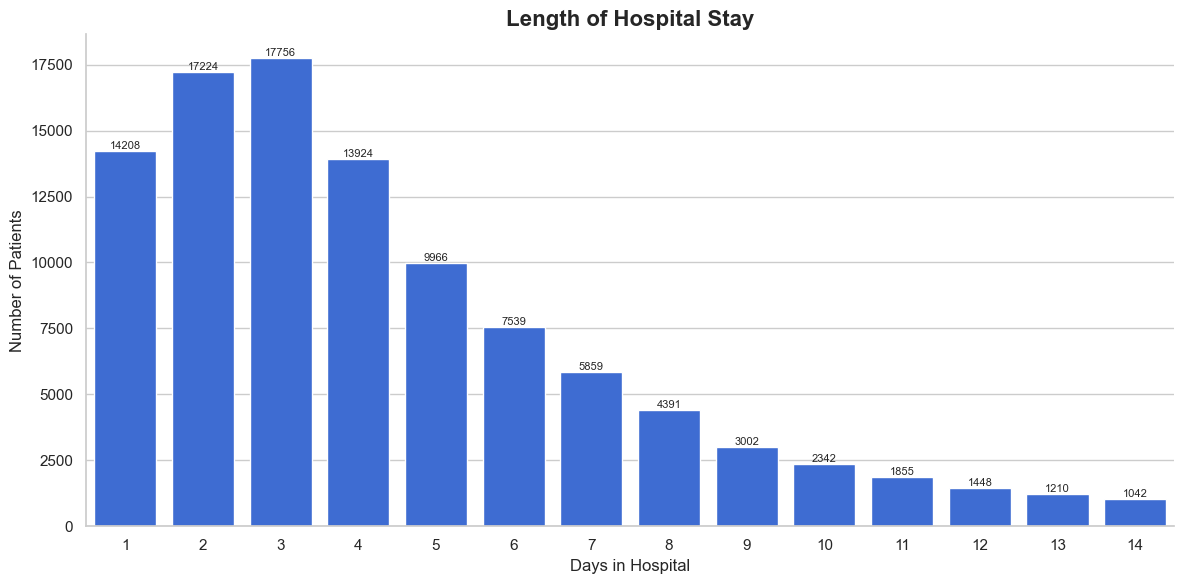

In [9]:
# ============================================================
# Time in Hospital Distribution
# ============================================================

hospital_stay = df["time_in_hospital"].value_counts().sort_index()

print(hospital_stay)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=hospital_stay.index,
    y=hospital_stay.values,
    color=PRIMARY_COLOR
)

plt.title("Length of Hospital Stay", fontsize=16, fontweight="bold")
plt.xlabel("Days in Hospital")
plt.ylabel("Number of Patients")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=8)

sns.despine()

plt.tight_layout()

plt.savefig(
    "../images/time_in_hospital_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Time in Hospital Observation

## 📊 Finding

- The highest number of patients stayed in the hospital for **3 days (17,756 patients)**.
- Hospital stays of **2 days (17,224)** and **1 day (14,208)** were also very common.
- The number of patients gradually decreases as the length of hospital stay increases.
- Only a small proportion of patients stayed for **more than 10 days**.

---

## 💡 Business Interpretation

Most diabetic patients required short-term hospitalization, while extended hospital stays were relatively uncommon. Longer hospital stays may indicate more severe health conditions or complications that require additional medical care.

---

## 🎯 Why It Matters

- Length of hospital stay is expected to be an important predictor of hospital readmission.
- Patients with longer hospital stays may have a greater risk of future readmission.
- This feature should be retained for predictive modeling.

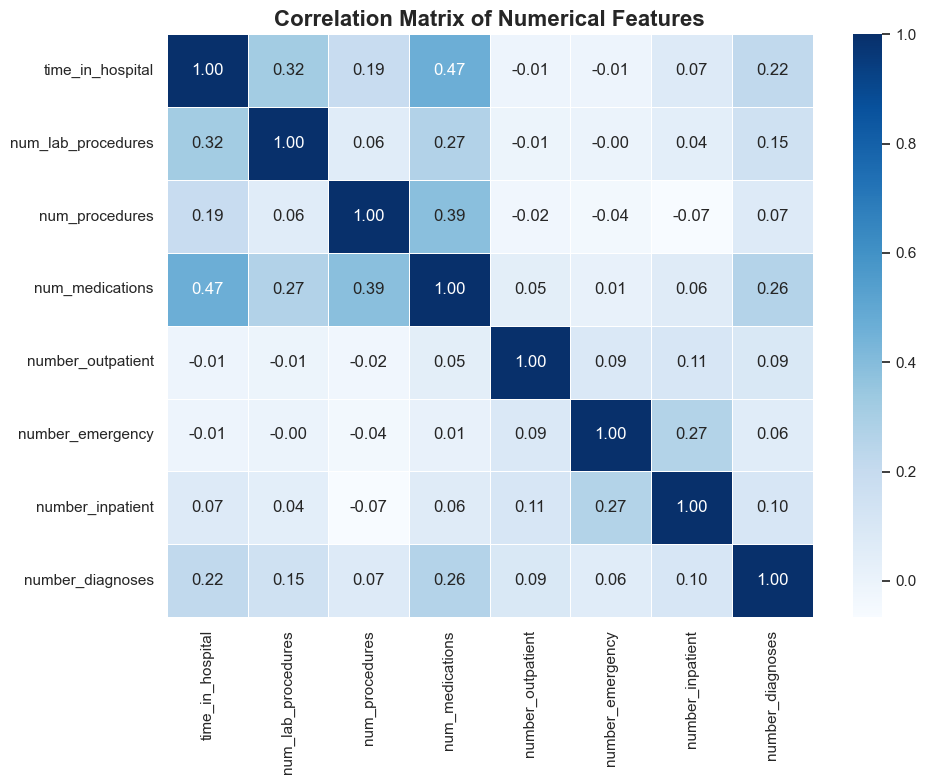

In [10]:
# ============================================================
# Correlation Matrix
# ============================================================

numerical_columns = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

correlation = df[numerical_columns].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../images/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Correlation Matrix Observation

## 📊 Finding

- The strongest positive correlation is observed between **time_in_hospital** and **num_medications (0.47)**.
- **num_procedures** and **num_medications** show a moderate positive correlation (**0.39**).
- **time_in_hospital** is also moderately correlated with **num_lab_procedures (0.32)**.
- Most other feature pairs have weak correlations (less than 0.30).
- No feature pair shows a correlation greater than **0.70**.

---

## 💡 Business Interpretation

Patients who stay longer in the hospital generally receive more medications and undergo more laboratory tests. However, the overall correlation between numerical features remains relatively low, indicating that each feature contributes different clinical information.

---

## 🎯 Why It Matters

- Low multicollinearity reduces redundancy among features.
- Multiple numerical variables can be retained without causing significant multicollinearity issues.
- This is beneficial for both machine learning models and feature interpretation.

In [11]:
# ============================================================
# Summary Statistics
# ============================================================

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

summary = df[numerical_columns].describe().T

summary = summary[[
    "count",
    "mean",
    "std",
    "min",
    "25%",
    "50%",
    "75%",
    "max"
]]

summary = summary.round(2)

summary

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.020000e+00,1.450000e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.720000e+00,5.280000e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.750000e+00,4.060000e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.400000e+00,2.990000e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.310000e+01,1.967000e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.340000e+00,1.710000e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602000e+01,8.130000e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.700000e-01,1.270000e+00,0.0,0.0,0.0,0.000000e+00,42.0


# Business Insights

## Key Business Insights

### 1. Readmission is a major healthcare concern.

Almost **46%** of diabetic patients were readmitted after discharge, indicating that preventing readmission should be a key healthcare objective.

---

### 2. Elderly patients dominate hospital admissions.

Patients aged **60–80 years** represent the largest proportion of hospitalizations, suggesting that older adults require greater clinical attention.

---

### 3. Most hospital stays are short.

The majority of patients stayed only **1–3 days**, while long hospital stays were relatively uncommon.

---

### 4. Longer hospitalization may indicate higher clinical complexity.

Patients with longer hospital stays generally received more medications and laboratory procedures.

---

### 5. Numerical features are not highly correlated.

The dataset contains relatively independent numerical variables, making them suitable for machine learning without severe multicollinearity concerns.

In [12]:
# ============================================================
# Save Summary Statistics
# ============================================================

summary.to_csv("../reports/summary_statistics.csv")

print("Summary statistics saved successfully!")

summary.head()

Summary statistics saved successfully!


,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.020000e+00,1.450000e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.720000e+00,5.280000e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.750000e+00,4.060000e+00,1.0,1.0,7.0,7.000000e+00,25.0


# Exploratory Data Analysis (EDA) Summary

## Dataset Summary

- Total Records: **101,766**
- Final Features: **45**
- Target Variable: **readmitted**

---

## Data Cleaning Performed

- Removed columns with excessive missing values (>30%)
- Replaced remaining missing values using mode
- Removed duplicated records
- Standardized missing value representation

---

## Exploratory Analysis Completed

- Target Variable Distribution
- Age Distribution
- Gender Distribution
- Race Distribution
- Hospital Stay Distribution
- Correlation Matrix

---

The dataset is now clean, consistent, and ready for feature engineering and predictive modeling.

In [13]:
# ============================================================
# Final Dataset Quality Check
# ============================================================

print("=" * 50)
print("FINAL DATASET QUALITY REPORT")
print("=" * 50)

print(f"\nRows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nMissing Values")
print("----------------")

print(df.isnull().sum().sum())

print("\nDuplicate Rows")
print("----------------")

print(df.duplicated().sum())

print("\nData Types")
print("----------------")

print(df.dtypes.value_counts())

FINAL DATASET QUALITY REPORT

Rows    : 101766
Columns : 45

Missing Values
----------------
0

Duplicate Rows
----------------
0

Data Types
----------------
str      32
int64    13
Name: count, dtype: int64


# Next Steps

The next phase of the project will focus on:

1. Feature Engineering
2. Feature Encoding
3. Feature Scaling
4. Outlier Detection
5. Machine Learning Model Preparation

These preprocessing steps will improve data quality before predictive modeling.

In [14]:
# ============================================================
# Notebook Completion
# ============================================================

print("=" * 60)
print("NOTEBOOK 03 COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"Dataset Shape : {df.shape}")

print("\nCompleted Tasks")

tasks = [
    "Dataset Overview",
    "Target Variable Analysis",
    "Age Distribution",
    "Gender Distribution",
    "Race Distribution",
    "Hospital Stay Analysis",
    "Correlation Analysis",
    "Summary Statistics",
    "Dataset Quality Check"
]

for i, task in enumerate(tasks, start=1):
    print(f"{i}. {task}")

print("\nDataset is ready for Feature Engineering.")

NOTEBOOK 03 COMPLETED SUCCESSFULLY
Dataset Shape : (101766, 45)

Completed Tasks
1. Dataset Overview
2. Target Variable Analysis
3. Age Distribution
4. Gender Distribution
5. Race Distribution
6. Hospital Stay Analysis
7. Correlation Analysis
8. Summary Statistics
9. Dataset Quality Check

Dataset is ready for Feature Engineering.


# Notebook Completion

## Notebook 03 Successfully Completed

This notebook covered the complete exploratory data analysis (EDA) process for the Healthcare Readmission dataset.

### Completed Tasks

- Dataset Overview
- Target Analysis
- Age Analysis
- Gender Analysis
- Race Analysis
- Hospital Stay Analysis
- Correlation Analysis
- Business Insights
- EDA Summary

The dataset is now fully explored and ready for feature engineering in the next notebook.
